# Clasificación de Residuos — Modelo D3: EfficientNetV2B0 GAP

---

## Contexto del Experimento

Este notebook forma parte de una **serie de experimentos de Transfer Learning** que aplica la técnica de la tijera: partimos del modelo más complejo (D0) y reducimos progresivamente la cabeza para encontrar el punto óptimo de simplicidad sin perder rendimiento.

### Estrategia Experimental

- **Punto de partida**: D2 (GAP → Dense(128) → Dropout(0.3)) — F1=0.8871
- **Enfoque**: ¿Podemos simplificar drásticamente la cabeza a solo Dense(6) sin perder rendimiento?
- **Observable**: Impacto de reducir la capa densa de 128 a 6 neuronas

Cada modelo se implementa en un archivo independiente dentro de la carpeta `models/` del proyecto.

---

## Arquitectura del Modelo D3

### Descripción

**EfficientNetV2B0 GAP** reduce la capa densa intermedia a solo 6 neuronas (igual que el número de clases), con Dropout(0.3). Es el paso más agresivo de simplificación de la serie. El backbone EfficientNetV2B0 está completamente descongelado desde el inicio, con LR bajo para preservar los pesos preentrenados.

### Posición en la Serie Descendente

| Componente | D2 (Anterior) | D3 (Este modelo) | D4 (Siguiente) |
|------------|--------------|-----------------|----------------|
| **Backbone** | EfficientNetV2B0 descongelado | EfficientNetV2B0 descongelado | EfficientNetV2B0 descongelado |
| **Cabeza** | GAP → Dense(128) → Dropout(0.3) → softmax | GAP → Dense(6) → Dropout(0.3) → softmax | GAP → Dropout(0.3) → softmax |
| **Parámetros** | 6,084,054 | 5,927,040 | 5,926,998 |

**Hipótesis**: Una capa densa de solo 6 neuronas actúa como cuello de botella excesivo, pero permite comprobar si el backbone por sí solo es capaz de mantener el rendimiento con una transformación mínima antes del clasificador.

---

## Resumen resultado final rendimiento en el conjunto de test

| Modelo | Parámetros | Accuracy | Precision | Recall | F1-Score |
|--------|----------:|--------:|----------:|-------:|--------:|
| A1 (SimpleCNN) | 210 | 0.4921 | 0.4257 | 0.4326 | 0.4150 |
| A2 (CNN Small) | 1,094 | 0.6100 | 0.6600 | 0.5600 | 0.5700 |
| A3 (CNN Medium) | 19,782 | 0.7263 | 0.7114 | 0.6884 | 0.6973 |
| A4 (CNN Large) | 94,918 | 0.7816 | 0.7643 | 0.7741 | 0.7578 |
| D0 (EffNet Full) | 6,253,910 | 0.9316 | 0.9199 | 0.9121 | 0.9139 |
| D1 (EffNet Top) | 6,248,790 | 0.9132 | 0.8815 | 0.9026 | 0.8874 |
| D2 (EffNet Head) | 6,084,054 | 0.9079 | 0.8797 | 0.9040 | 0.8871 |
| **D3 (EffNet GAP)** | **5,927,040** | **0.9132** | **0.8861** | **0.8344** | **0.8402** |

### Rendimiento por clase (Test)

| Clase | Precision | Recall | F1-Score | Support |
|-------|----------:|-------:|---------:|--------:|
| cardboard | 0.98 | 0.98 | 0.98 | 60 |
| glass | 0.96 | 0.86 | 0.90 | 76 |
| metal | 0.88 | 0.98 | 0.93 | 62 |
| paper | 0.92 | 0.99 | 0.95 | 89 |
| plastic | 0.86 | 0.95 | 0.90 | 73 |
| trash | 0.71 | 0.25 | 0.37 | 20 |

**Nota**: D3 confirma que Dense(6) es un cuello de botella demasiado agresivo. La clase `trash` se hunde de F1=0.72 (D2) a 0.37, víctima del Dropout(0.3) aplicado sobre solo 6 valores. El accuracy global (0.9132) es similar a D1 y D2, pero el F1 macro (0.8402) es el peor de toda la serie D, enmascarado por el buen rendimiento en clases con alto soporte. D4 explorará si eliminar completamente la Dense intermedia y aplicar Dropout directamente sobre las features del backbone resuelve este problema.

---

## Implementación

A continuación se entrena y evalúa el modelo D3 usando el pipeline estándar del proyecto.

---
## 0. Configuración del entorno (Colab)


In [1]:
# Celda 1 — Limpieza y configuración GPU
import gc
import keras
keras.backend.clear_session()
gc.collect()

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"Memory growth activado en {len(gpus)} GPU(s)")

print(tf.__version__)

2026-03-13 17:19:19.291594: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 17:19:19.318454: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-13 17:19:19.947493: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Memory growth activado en 1 GPU(s)
2.20.0


In [2]:
# ========================================
# 1. IMPORTS Y CONFIGURACION
# ========================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import keras

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Agregar ruta del proyecto al path (carpeta padre de notebooks)
sys.path.insert(0, '..')

# Importar funciones de utilidad
from src.utils import initialize_project

---
## 1. Carga de datos


In [3]:
# ========================================
# 2. CARGA DE DATOS Y CONFIGURACION
# ========================================

X_train, y_train, X_val, y_val, X_test, y_test, class_names = initialize_project()

Ejecutando en local

Cargando datos desde: /home/gosacar/Profundo/notebooks/../data/processed/trashnet_224x224.npz
  X.shape: (2527, 224, 224, 3)
  y.shape: (2527,)
  Clases: cardboard, glass, metal, paper, plastic, trash

División estratificada (seed=44):
  Train: 1768 imágenes (70%)
  Val:   379 imágenes (15%)
  Test:  380 imágenes (15%)


In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

SEED       = 44   # ← tu semilla
BATCH_SIZE = 32
NUM_CLASSES = len(class_names)

augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
], name='augmentation')

def make_dataset(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(len(X), seed=SEED)
        ds = ds.map(lambda x, y: (augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

ds_train = make_dataset(X_train, y_train, training=True)
ds_val   = make_dataset(X_val,   y_val)
ds_test  = make_dataset(X_test,  y_test)

print('Datasets listos')

I0000 00:00:1773418765.297015 2740654 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5848 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


Datasets listos


---
## 2. Definición del modelo


In [5]:
# ── CAMBIAR ESTAS DOS LÍNEAS SEGÚN EL MODELO ─────────────────────────────
from models.D3_effnet_gap       import build_effnet_gap       as build_model
# Ejemplos para otros modelos:
# from A2_cnn_small        import build_cnn_small        as build_model
# from A3_cnn_medium       import build_cnn_medium       as build_model
# from A4_cnn_large        import build_cnn_large        as build_model
# from A5_D5_cnn_frontier  import build_cnn_frontier     as build_model
# from D4_effnet_minimal   import build_effnet_minimal   as build_model
# from D3_effnet_gap       import build_effnet_gap       as build_model
# from D2_effnet_head      import build_effnet_head      as build_model
# from D1_effnet_top       import build_effnet_top       as build_model
# from D0_effnet_full      import build_effnet_full      as build_model


model = build_model(input_shape=(224, 224, 3), num_classes=6)
model.summary()

Model: "D3_EffNet_GAP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GAP (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 6)              │         7,686 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,927,040 (22.61 MB)

 Trainable params: 5,866,432 (22.38 MB)

 Non-trainable params: 60,608 (236.75 KB)

---
## 3. Entrenamiento 

In [6]:
HAS_PHASE2 = False                  # ← era True
MODEL_NAME = 'D3_EffNet_GAP'

cb_early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=30,                    # ← era 100
    restore_best_weights=True,
    mode='max',
    verbose=1
)

cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=30, min_lr=1e-6, verbose=1)

cb_checkpoint = callbacks.ModelCheckpoint(
    filepath=f'best_{MODEL_NAME}_phase1.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5,         # ← era 3e-4
        weight_decay=1e-4
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_p1 = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=300,
    callbacks=[cb_early_stop, cb_reduce_lr, cb_checkpoint],
    verbose=1
)

Epoch 1/300


2026-03-13 17:19:40.602106: I external/local_xla/xla/service/service.cc:163] XLA service 0x7a5d08002ed0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-13 17:19:40.602124: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9
2026-03-13 17:19:41.128520: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-13 17:19:43.255368: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-03-13 17:19:46.604148: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 17:19:46.687261: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed ou

 3/56 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.1580 - loss: 1.8377

I0000 00:00:1773418799.968600 2740990 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.1803 - loss: 1.8273

2026-03-13 17:20:07.648381: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 17:20:07.730586: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 17:20:07.978607: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 17:20:08.065051: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 17:20:08.452416: E external/local_xla/xla/stream_

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.1806 - loss: 1.8269

2026-03-13 17:20:19.786566: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_fusion', 432 bytes spill stores, 416 bytes spill loads

2026-03-13 17:20:24.680877: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 17:20:24.762547: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 17:20:25.041484: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 17:20:25.127746: E external/local_

56/56 ━━━━━━━━━━━━━━━━━━━━ 59s 485ms/step - accuracy: 0.1963 - loss: 1.8052 - val_accuracy: 0.2005 - val_loss: 1.7829 - learning_rate: 1.0000e-05
Epoch 2/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.2364 - loss: 1.7618 - val_accuracy: 0.2612 - val_loss: 1.7442 - learning_rate: 1.0000e-05
Epoch 3/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.2930 - loss: 1.7059 - val_accuracy: 0.2929 - val_loss: 1.7109 - learning_rate: 1.0000e-05
Epoch 4/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.3337 - loss: 1.6581 - val_accuracy: 0.3456 - val_loss: 1.6651 - learning_rate: 1.0000e-05
Epoch 5/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.3705 - loss: 1.6213 - val_accuracy: 0.3747 - val_loss: 1.6250 - learning_rate: 1.0000e-05
Epoch 6/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.3818 - loss: 1.5720 - val_accuracy: 0.4380 - val_loss: 1.5641 - learning_rate: 1.0000e-05
Epoch 7/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.4350 - l

---
## 4. Curvas de entrenamiento

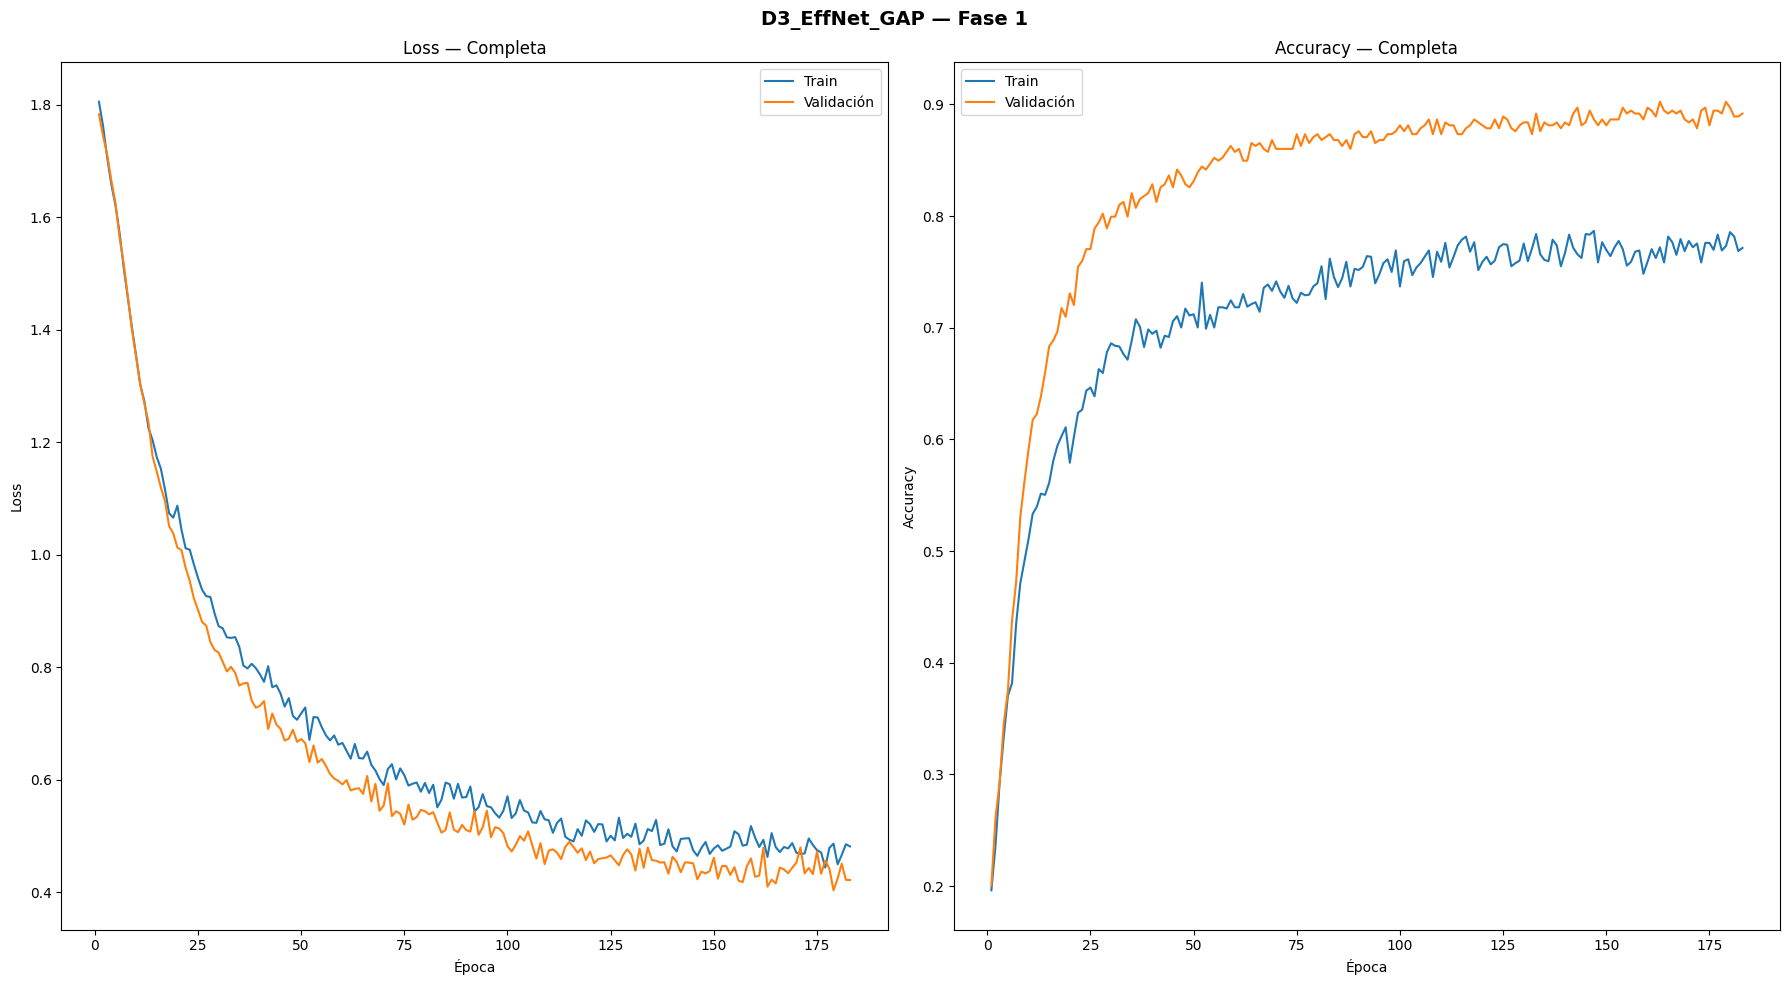

In [7]:
def smooth(values, weight=0.85):
    """Suavizado exponencial (similar a TensorBoard)."""
    smoothed, last = [], values[0]
    for v in values:
        last = last * weight + (1 - weight) * v
        smoothed.append(last)
    return smoothed


def plot_training(history, title='', phase=1):
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    epochs   = range(1, len(loss) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(18, 10))
    fig.suptitle(f'{title} — Fase {phase}', fontsize=14, fontweight='bold')

    # ── Fila 1: Loss ─────────────────────────────────────────────────────────
    # 1a) Curva completa
    axes[0].plot(epochs, loss,     label='Train')
    axes[0].plot(epochs, val_loss, label='Validación')
    axes[0].set_title('Loss — Completa')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend()

    # ── Fila 2: Accuracy ─────────────────────────────────────────────────────
    axes[1].plot(epochs, acc,     label='Train')
    axes[1].plot(epochs, val_acc, label='Validación')
    axes[1].set_title('Accuracy — Completa')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].legend()


    plt.tight_layout()
    plt.savefig(f'curvas_{MODEL_NAME}_fase{phase}.png', dpi=150)
    plt.show()


plot_training(history_p1, title=MODEL_NAME, phase=1)



---
## 5. Evaluación — Train / Val / Test

In [8]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_split(model, X, y, split_name):
    """Calcula y muestra Accuracy, Precision, Recall y F1-macro."""
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y, y_pred, average='macro', zero_division=0)
    print(f'[{split_name:>5}]  Acc={acc:.4f}  Prec={prec:.4f}  '
          f'Rec={rec:.4f}  F1={f1:.4f}')
    return {'split': split_name, 'acc': acc,
            'prec': prec, 'rec': rec, 'f1': f1, 'y_pred': y_pred}

print('-' * 60)
print(f'Modelo: {MODEL_NAME}')
print('-' * 60)
res_train = evaluate_split(model, X_train, y_train, 'Train')
res_val   = evaluate_split(model, X_val,   y_val,   'Val')
res_test  = evaluate_split(model, X_test,  y_test,  'Test')
print('-' * 60)

------------------------------------------------------------
Modelo: D3_EffNet_GAP
------------------------------------------------------------
[Train]  Acc=0.9757  Prec=0.9738  Rec=0.9342  F1=0.9480
[  Val]  Acc=0.9024  Prec=0.8896  Rec=0.8421  F1=0.8526


2026-03-13 17:31:53.008037: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 17:31:53.090863: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 17:31:53.365434: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-13 17:31:53.450568: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


[ Test]  Acc=0.9132  Prec=0.8861  Rec=0.8344  F1=0.8402
------------------------------------------------------------


In [9]:
# ── Número de parámetros (para la tabla del README) ──────────────────────────
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])

print(f'Parámetros totales    : {total_params:,}')
print(f'Parámetros entrenables: {trainable_params:,}')

Parámetros totales    : 5,927,040
Parámetros entrenables: 5,866,432


---
## 6. Matriz de confusión


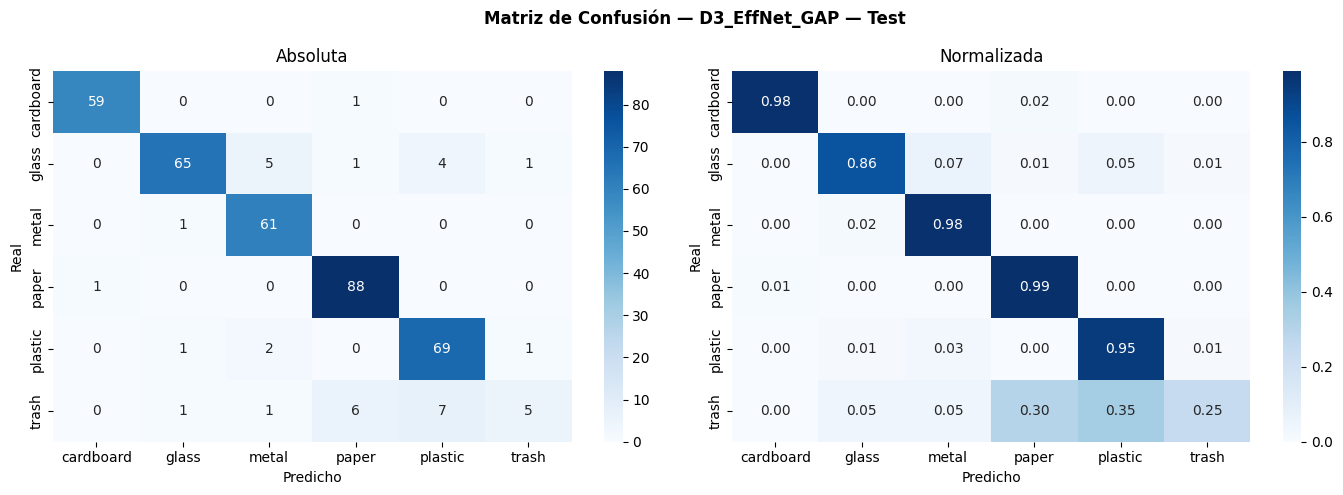

              precision    recall  f1-score   support

   cardboard       0.98      0.98      0.98        60
       glass       0.96      0.86      0.90        76
       metal       0.88      0.98      0.93        62
       paper       0.92      0.99      0.95        89
     plastic       0.86      0.95      0.90        73
       trash       0.71      0.25      0.37        20

    accuracy                           0.91       380
   macro avg       0.89      0.83      0.84       380
weighted avg       0.91      0.91      0.90       380



In [10]:
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, title='Test'):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Matriz de Confusión — {title}', fontweight='bold')

    for ax, data, fmt, ttl in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2f'],
        ['Absoluta', 'Normalizada']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_title(ttl)
        ax.set_xlabel('Predicho')
        ax.set_ylabel('Real')

    plt.tight_layout()
    plt.savefig(f'confusion_{MODEL_NAME}.png', dpi=150)
    plt.show()


plot_confusion_matrix(y_test, res_test['y_pred'], title=f'{MODEL_NAME} — Test')
print(classification_report(y_test, res_test['y_pred'],
                             target_names=class_names))


---
## 7. Resumen 


In [ ]:
print('─' * 90)
for res in [res_train, res_val, res_test]:
    print(
        f"| **{MODEL_NAME}** | {total_params:,} | {res['split']:>5} "
        f"| {res['acc']:.4f} | {res['prec']:.4f} "
        f"| {res['rec']:.4f} | {res['f1']:.4f} |"
    )
print('─' * 90)

──────────────────────────────────────────────────────────────────────────────────────────
| **D3_EffNet_GAP** | 5,927,040 | Train | 0.9757 | 0.9738 | 0.9342 | 0.9480 |
| **D3_EffNet_GAP** | 5,927,040 |   Val | 0.9024 | 0.8896 | 0.8421 | 0.8526 |
| **D3_EffNet_GAP** | 5,927,040 |  Test | 0.9132 | 0.8861 | 0.8344 | 0.8402 |
──────────────────────────────────────────────────────────────────────────────────────────


: 